In [1]:
# ============================================
# CELL 1: Setup
# ============================================
!pip install -q sentence-transformers faiss-cpu transformers accelerate sentencepiece matplotlib pandas

import re
import time
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sentence_transformers import SentenceTransformer

print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 40.7 MB/s eta 0:00:00
Setup complete.


In [2]:
# ============================================
# CELL 2: Corpus + labeled eval set designed to STRESS query transformation
# Query "types" are labeled so we can see WHERE each technique helps.
# ============================================

corpus = [
    "Acme's return policy lets customers send back unused items within 30 days of delivery for a full refund.",   # 0
    "Refunds are issued to the original payment method within 5-7 business days after the returned item arrives at our warehouse.",  # 1
    "Items marked final sale, including clearance products, cannot be returned or exchanged.",                     # 2
    "Acme Premium members enjoy free two-day shipping on all orders and extended 60-day returns.",                 # 3
    "Standard shipping takes 5-8 business days and costs $5.99 for orders under $50.",                             # 4
    "Express shipping delivers within 2 business days and costs $14.99.",                                          # 5
    "International orders ship to over 40 countries; customs duties and import taxes are paid by the recipient.",  # 6
    "To reset your password, click 'Forgot password' on the login page and follow the emailed link, which expires after 24 hours.",  # 7
    "Two-factor authentication can be enabled under Account Settings > Security using an authenticator app.",      # 8
    "If your account is locked after five failed login attempts, wait 30 minutes or contact support to unlock it.", # 9
    "Acme Premium costs $99 per year and can be cancelled at any time from the Membership page.",                  # 10
    "Gift cards never expire and can be redeemed at checkout by entering the 16-digit code.",                      # 11
    "Damaged or defective items are eligible for free replacement within 90 days of purchase; contact support with photos of the damage.",  # 12
    "Customer support is available by chat 24/7 and by phone from 9am to 6pm Eastern on weekdays.",                # 13
    "Order tracking numbers are emailed once your package leaves the warehouse; tracking may take 24 hours to update.",  # 14
    "You can change your shipping address only before the order has been marked as shipped.",                      # 15
    "Price adjustments are honored within 14 days of purchase if an item goes on sale.",                           # 16
    "Acme accepts Visa, Mastercard, American Express, PayPal, and Apple Pay.",                                     # 17
    "Orders can be cancelled free of charge within one hour of placing them from the Orders page.",                # 18
    "The Acme mobile app supports biometric login with fingerprint or face recognition.",                          # 19
]

# relevance: {doc_id: grade}  (3 = directly answers, 2 = relevant, 1 = marginal)
eval_dataset = [
    {"type": "vocab_mismatch", "query": "I forgot my login credentials, how do I get back in?",
     "history": [], "relevance": {7: 3, 9: 2}},
    {"type": "vocab_mismatch", "query": "What if the thing I bought arrived broken?",
     "history": [], "relevance": {12: 3}},
    {"type": "short_vague", "query": "money back timeline",
     "history": [], "relevance": {1: 3}},
    {"type": "multi_hop", "query": "As a Premium member, how long do I have to return something and how fast will I get refunded?",
     "history": [], "relevance": {3: 3, 1: 3, 0: 2}},
    {"type": "multi_hop", "query": "How much does Premium cost and does it include free shipping?",
     "history": [], "relevance": {10: 3, 3: 3}},
    {"type": "conversational", "query": "And how do I cancel it?",
     "history": [("user", "Tell me about the Acme Premium membership."),
                 ("assistant", "Acme Premium is a paid membership with free two-day shipping and extended returns.")],
     "relevance": {10: 3}},
    {"type": "conversational", "query": "Can I still change where it's sent?",
     "history": [("user", "I just placed an order for a jacket."),
                 ("assistant", "Great! Is there anything I can help you with about it?")],
     "relevance": {15: 3, 18: 1}},
]
print(f"Corpus: {len(corpus)} docs | Eval queries: {len(eval_dataset)}")

Corpus: 20 docs | Eval queries: 7


In [3]:
# ============================================
# CELL 3: Metrics (compact versions of Part 7's library)
# ============================================
def recall_at_k(ranked, rel, k):
    return len(set(rel) & set(ranked[:k])) / len(rel) if rel else 0.0

def reciprocal_rank(ranked, rel):
    for i, d in enumerate(ranked, 1):
        if d in rel:
            return 1.0 / i
    return 0.0

def dcg(ranked, rel, k):
    return sum(rel.get(d, 0) / np.log2(i + 1) for i, d in enumerate(ranked[:k], 1))

def ndcg_at_k(ranked, rel, k):
    ideal = dcg(sorted(rel, key=rel.get, reverse=True), rel, k)
    return dcg(ranked, rel, k) / ideal if ideal > 0 else 0.0

In [4]:
# ============================================
# CELL 4: LLM client abstraction (local free model OR Anthropic API)
# Every query-transformation technique goes through this one interface,
# so swapping LLMs = changing one line. Counts calls for cost analysis.
#
# To use the API instead (much better quality):
#   import os; from google.colab import userdata
#   os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
#   !pip install -q anthropic
#   llm = LLMClient(provider="anthropic")
# ============================================
class LLMClient:
    def __init__(self, provider="local", local_model="google/flan-t5-large",
                 api_model="claude-haiku-4-5-20251001", use_cache=False):
        self.provider, self.use_cache = provider, use_cache
        self._cache: Dict[Tuple, List[str]] = {}
        self.call_count = 0
        if provider == "local":
            import torch
            from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
            self.torch = torch
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
            self.tok = AutoTokenizer.from_pretrained(local_model)
            self.model = AutoModelForSeq2SeqLM.from_pretrained(local_model).to(self.device).eval()
        elif provider == "anthropic":
            import anthropic
            self.client = anthropic.Anthropic()  # reads ANTHROPIC_API_KEY from env
            self.api_model = api_model
        else:
            raise ValueError("provider must be 'local' or 'anthropic'")
        print(f"LLMClient ready (provider={provider})")

    def generate(self, prompt: str, max_new_tokens: int = 96, temperature: float = 0.0, n: int = 1) -> List[str]:
        key = (prompt, max_new_tokens, temperature, n)
        if self.use_cache and temperature == 0.0 and key in self._cache:
            return self._cache[key]
        self.call_count += 1
        outs = (self._gen_local if self.provider == "local" else self._gen_api)(prompt, max_new_tokens, temperature, n)
        if self.use_cache and temperature == 0.0:
            self._cache[key] = outs
        return outs

    def _gen_local(self, prompt, max_new_tokens, temperature, n):
        enc = self.tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(self.device)
        kw = dict(max_new_tokens=max_new_tokens)
        if temperature > 0:
            kw.update(do_sample=True, temperature=temperature, top_p=0.95, num_return_sequences=n)
        elif n > 1:
            kw.update(num_beams=max(n, 4), num_return_sequences=n)
        with self.torch.no_grad():
            out = self.model.generate(**enc, **kw)
        return [self.tok.decode(o, skip_special_tokens=True).strip() for o in out]

    def _gen_api(self, prompt, max_new_tokens, temperature, n):
        prompt += "\n\nRespond with only the requested text, no preamble."
        results = []
        for _ in range(n):
            resp = self.client.messages.create(
                model=self.api_model, max_tokens=max(max_new_tokens, 256),
                temperature=min(temperature if n == 1 else max(temperature, 0.7), 1.0),
                messages=[{"role": "user", "content": prompt}])
            results.append(resp.content[0].text.strip())
        return results


llm = LLMClient(provider="local")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

LLMClient ready (provider=local)


In [5]:
# ============================================
# CELL 5: Dense retriever (supports searching with a raw vector -> needed for HyDE)
# ============================================
class DenseRetriever:
    def __init__(self, documents, model_name="all-MiniLM-L6-v2"):
        self.documents = documents
        self.model = SentenceTransformer(model_name)
        emb = self.embed(documents)
        self.index = faiss.IndexFlatIP(emb.shape[1])
        self.index.add(emb)

    def embed(self, texts: List[str]) -> np.ndarray:
        return self.model.encode(texts, normalize_embeddings=True, show_progress_bar=False).astype("float32")

    def search_vec(self, vec: np.ndarray, top_k=10) -> List[Tuple[int, float]]:
        v = np.ascontiguousarray(vec.reshape(1, -1).astype("float32"))
        faiss.normalize_L2(v)
        scores, idx = self.index.search(v, top_k)
        return [(int(i), float(s)) for i, s in zip(idx[0], scores[0]) if i != -1]

    def search(self, query: str, top_k=10) -> List[Tuple[int, float]]:
        return self.search_vec(self.embed([query])[0], top_k)


retriever = DenseRetriever(corpus)
CAND_K = 10   # candidates retrieved per query variant
print("Retriever ready.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Retriever ready.


In [6]:
# ============================================
# CELL 6: QueryTransformer — rewrite, multi-query, HyDE, decomposition
# Includes production guardrails: fallback on garbage output + ID preservation.
# ============================================
ID_PATTERN = re.compile(r"\b[A-Za-z]{1,6}-?\d{2,}[A-Za-z0-9-]*\b")   # e.g. E-4021, SKU-88213-A

class QueryTransformer:
    def __init__(self, llm: LLMClient):
        self.llm = llm

    @staticmethod
    def _safe(original: str, candidate: str) -> str:
        """Guardrails: reject empty/runaway output, and re-attach exact IDs the LLM dropped."""
        if not candidate or len(candidate) > 4 * len(original) + 80:
            return original
        missing = [t for t in ID_PATTERN.findall(original) if t.lower() not in candidate.lower()]
        return (candidate + " " + " ".join(missing)) if missing else candidate

    def rewrite_with_history(self, query: str, history: List[Tuple[str, str]]) -> str:
        if not history:
            return query
        convo = "\n".join(f"{role}: {text}" for role, text in history[-6:])   # cap history length
        prompt = ("Rewrite the follow-up question so it can be understood without the conversation. "
                  "Replace pronouns with the specific thing they refer to.\n\n"
                  f"Conversation:\n{convo}\n\nFollow-up question: {query}\n\nStandalone question:")
        return self._safe(query, self.llm.generate(prompt, max_new_tokens=48)[0])

    def multi_query(self, query: str, n: int = 3) -> List[str]:
        prompt = f"Paraphrase this question using different words:\n{query}\n\nParaphrase:"
        outs = self.llm.generate(prompt, max_new_tokens=48, temperature=0.9, n=n)
        variants, seen = [query], {query.lower()}
        for o in outs:
            o = self._safe(query, o)
            if o.lower() not in seen:
                variants.append(o); seen.add(o.lower())
        return variants

    def hyde(self, query: str) -> str:
        prompt = ("Write a short passage from a company help center that answers the question.\n\n"
                  f"Question: {query}\n\nPassage:")
        return self.llm.generate(prompt, max_new_tokens=80)[0]

    def decompose(self, query: str, max_subs: int = 4) -> List[str]:
        prompt = ("Break the question into simple, separate sub-questions, one per line.\n\n"
                  f"Question: {query}\n\nSub-questions:")
        raw = self.llm.generate(prompt, max_new_tokens=96)[0]
        parts = [p.strip(" -•\t") for p in re.split(r"\n|\?", raw)]
        subs = [p + "?" for p in parts if len(p.split()) >= 3][:max_subs]
        return subs if len(subs) > 1 else [query]   # if it didn't really split, don't pretend it did


qt = QueryTransformer(llm)

# Quick smoke test — ALWAYS inspect what your transformer actually outputs
demo = eval_dataset[5]
print("Rewrite  :", qt.rewrite_with_history(demo["query"], demo["history"]))
print("MultiQ   :", qt.multi_query("What if the thing I bought arrived broken?"))
print("HyDE     :", qt.hyde("What if the thing I bought arrived broken?"))
print("Decompose:", qt.decompose(eval_dataset[4]["query"]))

Rewrite  : user: Acme Premium is a paid membership with free two-day shipping and extended returns.
MultiQ   : ['What if the thing I bought arrived broken?', 'What if I bought the thing it arrived broken?', 'What if the thing I bought was broken?', 'What if I bought a new thing and it arrived broken?']
HyDE     : If you receive a broken item, you can return it for a refund.
Decompose: ['How much does Premium cost and does it include free shipping?']


In [7]:
# ============================================
# CELL 7: Retrieval strategies. Each returns (ranked_doc_ids, debug_info)
# ============================================
def rrf_fuse(rankings: List[List[int]], k: int = 60, top_k: int = 10) -> List[int]:
    scores: Dict[int, float] = {}
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking, start=1):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
    return [d for d, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)][:top_k]

def _ids(hits): return [d for d, _ in hits]

def strat_baseline(q, h):
    return _ids(retriever.search(q, CAND_K)), {"queries": [q]}

def strat_rewrite(q, h):
    sq = qt.rewrite_with_history(q, h)
    return _ids(retriever.search(sq, CAND_K)), {"queries": [sq]}

def strat_multi_query(q, h):
    sq = qt.rewrite_with_history(q, h)
    variants = qt.multi_query(sq, n=3)
    rankings = [_ids(retriever.search(v, CAND_K)) for v in variants]
    return rrf_fuse(rankings, top_k=CAND_K), {"queries": variants}

def strat_hyde(q, h):
    sq = qt.rewrite_with_history(q, h)
    passage = qt.hyde(sq)
    vecs = retriever.embed([sq, passage])
    fused_vec = vecs.mean(axis=0)                     # HyDE: average query + hypothetical doc embedding
    return _ids(retriever.search_vec(fused_vec, CAND_K)), {"queries": [sq, "[HyDE] " + passage]}

def strat_decompose(q, h):
    sq = qt.rewrite_with_history(q, h)
    subs = qt.decompose(sq)
    rankings = [_ids(retriever.search(s, CAND_K)) for s in subs]
    rankings.append(_ids(retriever.search(sq, CAND_K)))   # always keep the full query as one voter
    return rrf_fuse(rankings, top_k=CAND_K), {"queries": subs}

STRATEGIES = {
    "baseline": strat_baseline,
    "rewrite": strat_rewrite,
    "multi_query": strat_multi_query,
    "hyde": strat_hyde,
    "decompose": strat_decompose,
}

In [8]:
# ============================================
# CELL 8: Evaluation harness — quality AND cost (latency, LLM calls) per strategy
# ============================================
K = 5

def run_eval(name: str, strategy) -> pd.DataFrame:
    rows = []
    for item in eval_dataset:
        calls_before = llm.call_count
        t0 = time.perf_counter()
        ranked, dbg = strategy(item["query"], item["history"])
        latency_ms = (time.perf_counter() - t0) * 1000
        rel = item["relevance"]
        rows.append({
            "strategy": name, "type": item["type"], "query": item["query"][:45],
            f"recall@{K}": recall_at_k(ranked, rel, K),
            "mrr": reciprocal_rank(ranked, rel),
            f"ndcg@{K}": ndcg_at_k(ranked, rel, K),
            "latency_ms": latency_ms,
            "llm_calls": llm.call_count - calls_before,
            "transformed_queries": dbg["queries"],
        })
    return pd.DataFrame(rows)

all_results = {name: run_eval(name, fn) for name, fn in STRATEGIES.items()}
results_df = pd.concat(all_results.values(), ignore_index=True)

summary = results_df.groupby("strategy").agg(
    recall=(f"recall@{K}", "mean"), MRR=("mrr", "mean"), ndcg=(f"ndcg@{K}", "mean"),
    avg_latency_ms=("latency_ms", "mean"), avg_llm_calls=("llm_calls", "mean")
).reindex(list(STRATEGIES)).round(3)
print(summary.to_string())

print("\n--- NDCG@5 by query TYPE (averages hide where techniques help) ---")
print(results_df.pivot_table(index="type", columns="strategy", values=f"ndcg@{K}").reindex(columns=list(STRATEGIES)).round(3).to_string())

             recall    MRR   ndcg  avg_latency_ms  avg_llm_calls
strategy                                                        
baseline      1.000  0.905  0.900          12.538          0.000
rewrite       1.000  0.929  0.924         394.127          0.286
multi_query   0.929  0.814  0.841        1632.090          1.286
hyde          1.000  0.929  0.919        1141.104          1.286
decompose     1.000  0.929  0.924        1342.442          1.286

--- NDCG@5 by query TYPE (averages hide where techniques help) ---
strategy        baseline  rewrite  multi_query   hyde  decompose
type                                                            
conversational     0.732    0.815        0.660  0.797      0.815
multi_hop          0.917    0.917        0.783  0.917      0.917
short_vague        1.000    1.000        1.000  1.000      1.000
vocab_mismatch     1.000    1.000        1.000  1.000      1.000


In [9]:
# ============================================
# CELL 9: Inspect the transformed queries (debugging habit: LOOK at the LLM's output)
# ============================================
for i in [0, 3, 5]:
    item = eval_dataset[i]
    print(f"\nORIGINAL [{item['type']}]: {item['query']}")
    for name in ["rewrite", "multi_query", "hyde", "decompose"]:
        tq = all_results[name].loc[i, "transformed_queries"]
        print(f"  {name:12s} -> {[t[:90] for t in tq]}")


ORIGINAL [vocab_mismatch]: I forgot my login credentials, how do I get back in?
  rewrite      -> ['I forgot my login credentials, how do I get back in?']
  multi_query  -> ['I forgot my login credentials, how do I get back in?', 'How do I change my password when I forget mine?', 'How can I login to a bank account if I forgot my login credentials?', 'How can I log back in to my facebook account that I forgot my username?']
  hyde         -> ['I forgot my login credentials, how do I get back in?', '[HyDE] You can log in to your account by entering your login credentials.']
  decompose    -> ['I forgot my login credentials, how do I get back in?']

ORIGINAL [multi_hop]: As a Premium member, how long do I have to return something and how fast will I get refunded?
  rewrite      -> ['As a Premium member, how long do I have to return something and how fast will I get refund']
  multi_query  -> ['As a Premium member, how long do I have to return something and how fast will I get refund', 'W

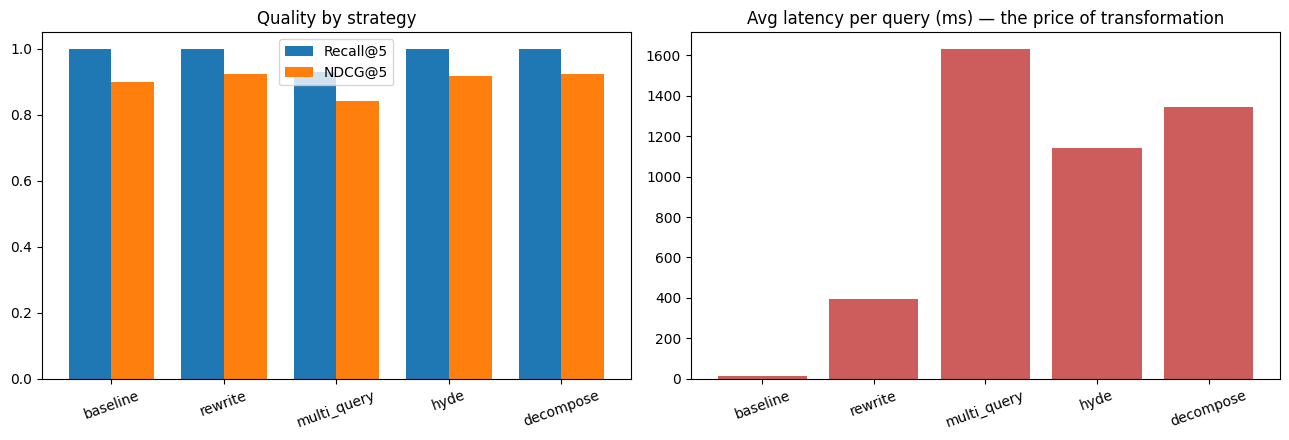

Ask of every technique: is the quality gain worth the added latency and LLM calls?


In [10]:
# ============================================
# CELL 10: Visualization — quality vs cost
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = list(STRATEGIES)

x = np.arange(len(order)); w = 0.38
axes[0].bar(x - w/2, summary.loc[order, "recall"], w, label=f"Recall@{K}")
axes[0].bar(x + w/2, summary.loc[order, "ndcg"], w, label=f"NDCG@{K}")
axes[0].set_xticks(x); axes[0].set_xticklabels(order, rotation=20)
axes[0].set_ylim(0, 1.05); axes[0].set_title("Quality by strategy"); axes[0].legend()

axes[1].bar(order, summary.loc[order, "avg_latency_ms"], color="indianred")
axes[1].set_title("Avg latency per query (ms) — the price of transformation")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
print("Ask of every technique: is the quality gain worth the added latency and LLM calls?")

# **RAGAS-style metrics**

In [11]:
# ============================================
# CELL 1: Setup
# ============================================
!pip install -q sentence-transformers transformers accelerate sentencepiece torch matplotlib pandas

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sentence_transformers import SentenceTransformer

print("Setup complete.")

Setup complete.


In [12]:
# ============================================
# CELL 2: A small "RAG output" test set covering the classic failure modes.
# Each sample = what a real RAG run logs: question, retrieved contexts (in rank order),
# generated answer, ground-truth answer, whether the question is answerable from docs,
# and a HUMAN label (used later to calibrate the automated judge).
# ============================================
samples = [
    {   # 1) Healthy: right context, faithful, relevant
        "id": "S1_good",
        "question": "How long do refunds take?",
        "contexts": ["Refunds are issued to the original payment method within 5-7 business days after the returned item arrives at our warehouse.",
                     "Acme's return policy lets customers send back unused items within 30 days of delivery for a full refund."],
        "answer": "Refunds are issued to your original payment method within 5-7 business days after the returned item reaches our warehouse.",
        "ground_truth": "Refunds take 5-7 business days after the returned item arrives at the warehouse.",
        "answerable": True, "human_faithful": True,
    },
    {   # 2) Hallucination: correct facts + two invented claims
        "id": "S2_hallucination",
        "question": "How long do I have to return an item?",
        "contexts": ["Acme's return policy lets customers send back unused items within 30 days of delivery for a full refund.",
                     "Items marked final sale, including clearance products, cannot be returned or exchanged."],
        "answer": "You can return unused items within 30 days of delivery for a full refund. Returns are free, and you will also receive a $10 store credit.",
        "ground_truth": "Unused items can be returned within 30 days of delivery for a full refund. Final sale items cannot be returned.",
        "answerable": True, "human_faithful": False,
    },
    {   # 3) Faithful but answers the WRONG question
        "id": "S3_off_topic",
        "question": "How do I reset my password?",
        "contexts": ["To reset your password, click 'Forgot password' on the login page and follow the emailed link, which expires after 24 hours.",
                     "Two-factor authentication can be enabled under Account Settings > Security using an authenticator app."],
        "answer": "Two-factor authentication can be enabled under Account Settings > Security using an authenticator app.",
        "ground_truth": "Click 'Forgot password' on the login page and follow the emailed link, which expires after 24 hours.",
        "answerable": True, "human_faithful": True,
    },
    {   # 4) Retrieval failure + parametric leakage: answer happens to be TRUE, but not in the retrieved context
        "id": "S4_ungrounded_true",
        "question": "Does Acme Premium include free shipping?",
        "contexts": ["Standard shipping takes 5-8 business days and costs $5.99 for orders under $50.",
                     "Express shipping delivers within 2 business days and costs $14.99."],
        "answer": "Yes, Premium members get free two-day shipping on all orders.",
        "ground_truth": "Yes, Acme Premium members enjoy free two-day shipping on all orders.",
        "answerable": True, "human_faithful": False,
    },
    {   # 5) Correct abstention: info is NOT in the docs, model says so
        "id": "S5_abstain_ok",
        "question": "Does Acme ship to Antarctica?",
        "contexts": ["International orders ship to over 40 countries; customs duties and import taxes are paid by the recipient.",
                     "Standard shipping takes 5-8 business days and costs $5.99 for orders under $50."],
        "answer": "The provided documents don't say whether Acme ships to Antarctica; they only mention shipping to over 40 countries.",
        "ground_truth": "The documentation does not specify whether Acme ships to Antarctica.",
        "answerable": False, "human_faithful": True,
    },
]
print(f"{len(samples)} evaluation samples loaded.")

5 evaluation samples loaded.


In [13]:
# ============================================
# CELL 3: Judge components
#   - NLIJudge: entailment classifier (does the context ENTAIL the claim?)
#   - LLM (flan-t5) for reverse-question generation (answer relevancy)
#   - Embedder for similarity
# ============================================
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoTokenizer as _T, AutoModelForSeq2SeqLM

class NLIJudge:
    """Deterministic, local claim verifier. Premise = context, hypothesis = claim."""
    def __init__(self, model_name="cross-encoder/nli-deberta-v3-base"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tok = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name).to(self.device).eval()
        id2label = {int(k): v.lower() for k, v in self.model.config.id2label.items()}
        self.entail_idx = [i for i, l in id2label.items() if "entail" in l][0]   # don't hardcode label order
        print("NLI label map:", id2label)

    def entailment_prob(self, premises: List[str], hypotheses: List[str], batch_size: int = 16) -> List[float]:
        out = []
        for i in range(0, len(premises), batch_size):
            enc = self.tok(premises[i:i+batch_size], hypotheses[i:i+batch_size],
                           truncation="only_first", padding=True, max_length=512, return_tensors="pt").to(self.device)
            with torch.no_grad():
                logits = self.model(**enc).logits
            out.extend(torch.softmax(logits, dim=-1)[:, self.entail_idx].cpu().tolist())
        return out

    def best_support(self, claim: str, contexts: List[str]) -> float:
        """Max entailment over each chunk AND the concatenation (covers claims needing 2 chunks)."""
        if not contexts:
            return 0.0
        premises = contexts + [" ".join(contexts)]
        return max(self.entailment_prob(premises, [claim] * len(premises)))


class SmallLLM:
    def __init__(self, model_name="google/flan-t5-large"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.tok = _T.from_pretrained(model_name)
        self.model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(self.device).eval()

    def generate(self, prompt, n=3, max_new_tokens=40, temperature=0.8) -> List[str]:
        enc = self.tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(self.device)
        with torch.no_grad():
            out = self.model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=True,
                                      temperature=temperature, top_p=0.95, num_return_sequences=n)
        return [self.tok.decode(o, skip_special_tokens=True).strip() for o in out]


nli = NLIJudge()
small_llm = SmallLLM()
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("Judges ready.")

config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

...

NLI label map: {0: 'contradiction', 1: 'entailment', 2: 'neutral'}


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Judges ready.


In [14]:
# ============================================
# CELL 4: The metrics — RAGAS-style, implemented from scratch so every step is visible
# ============================================
NONCOMMITTAL = re.compile(
    r"\b(don't know|do not know|not specified|(doesn't|does not|don't|do not) (say|specify|mention)|"
    r"no information|cannot (find|determine)|not mentioned)\b", re.I)

def is_noncommittal(answer: str) -> bool:
    return bool(NONCOMMITTAL.search(answer))

def extract_claims(text: str) -> List[str]:
    """Heuristic atomic-claim extraction: sentences, then split on ', and' / ';'.
    PRODUCTION: use an LLM to decompose AND decontextualize (resolve pronouns) each claim."""
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s.strip()]
    claims = []
    for s in sentences:
        for part in re.split(r",\s+and\s+|;\s+", s):
            if len(part.split()) >= 3:
                claims.append(part.strip().rstrip(".") + ".")
    return claims

def faithfulness(answer: str, contexts: List[str], thr: float = 0.5) -> Tuple[float, List[Dict]]:
    claims = extract_claims(answer)
    details = []
    for c in claims:
        s = nli.best_support(c, contexts)
        details.append({"claim": c, "support": round(s, 3), "supported": s >= thr})
    score = sum(d["supported"] for d in details) / len(details) if details else 0.0
    return score, details

def answer_relevancy(question: str, answer: str, n: int = 3) -> Tuple[float, List[str]]:
    """Generate questions the answer would respond to; compare to the real question."""
    if not answer.strip():
        return 0.0, []
    prompt = f"Write the question that the following answer responds to.\n\nAnswer: {answer}\n\nQuestion:"
    gen = [g for g in small_llm.generate(prompt, n=n) if g.strip()]
    if not gen:
        return 0.0, []
    q_emb = embedder.encode([question], normalize_embeddings=True)
    g_emb = embedder.encode(gen, normalize_embeddings=True)
    return float((g_emb @ q_emb.T).mean()), gen

def context_recall(ground_truth: str, contexts: List[str], thr: float = 0.5) -> float:
    gt_claims = extract_claims(ground_truth)
    if not gt_claims:
        return 0.0
    return sum(nli.best_support(c, contexts) >= thr for c in gt_claims) / len(gt_claims)

def context_precision(ground_truth: str, contexts: List[str], thr: float = 0.5) -> float:
    """Rank-aware: mean of Precision@k over the positions k that hold a USEFUL chunk."""
    gt_claims = extract_claims(ground_truth)
    if not gt_claims or not contexts:
        return 0.0
    useful = [max(nli.entailment_prob([ctx] * len(gt_claims), gt_claims)) >= thr for ctx in contexts]
    if not any(useful):
        return 0.0
    hits, precisions = 0, []
    for k, v in enumerate(useful, 1):
        hits += v
        if v:
            precisions.append(hits / k)
    return sum(precisions) / sum(useful)

def answer_similarity(answer: str, ground_truth: str) -> float:
    e = embedder.encode([answer, ground_truth], normalize_embeddings=True)
    return float(e[0] @ e[1])

In [15]:
# ============================================
# CELL 5: Evaluate every sample + automatic root-cause diagnosis (the diagnostic matrix in code)
# ============================================
THRESH = {"recall": 0.7, "faith": 0.8, "relevancy": 0.6, "precision": 0.6}   # calibrate on YOUR data

def diagnose(row: Dict, answerable: bool) -> str:
    if not answerable:
        return "OK: correct abstention" if row["abstained"] else "GENERATION: should have abstained (hallucinating)"
    if row["context_recall"] < THRESH["recall"]:
        return "RETRIEVAL: needed info missing from context"
    if row["faithfulness"] < THRESH["faith"]:
        return "GENERATION: unsupported claims (hallucination / parametric leakage)"
    if row["answer_relevancy"] < THRESH["relevancy"]:
        return "GENERATION: answer doesn't address the question"
    if row["context_precision"] < THRESH["precision"]:
        return "RANKING: useful chunks buried / noisy context"
    return "OK"

rows, claim_details = [], {}
for s in samples:
    f, det = faithfulness(s["answer"], s["contexts"])
    rel, gen_qs = answer_relevancy(s["question"], s["answer"])
    row = {
        "id": s["id"],
        "faithfulness": f,
        "answer_relevancy": rel,
        "context_precision": context_precision(s["ground_truth"], s["contexts"]) if s["answerable"] else np.nan,
        "context_recall": context_recall(s["ground_truth"], s["contexts"]) if s["answerable"] else np.nan,
        "answer_similarity": answer_similarity(s["answer"], s["ground_truth"]),
        "abstained": is_noncommittal(s["answer"]),
    }
    row["diagnosis"] = diagnose(row, s["answerable"])
    rows.append(row)
    claim_details[s["id"]] = (det, gen_qs)

df = pd.DataFrame(rows)
print(df.round(3).to_string(index=False))

print("\n--- Claim-level faithfulness detail (ALWAYS inspect this when debugging) ---")
for sid, (det, gen_qs) in claim_details.items():
    print(f"\n[{sid}]  generated questions for relevancy: {gen_qs}")
    for d in det:
        print(f"   {'✓' if d['supported'] else '✗'} support={d['support']:.2f} | {d['claim']}")

                id  faithfulness  answer_relevancy  context_precision  context_recall  answer_similarity  abstained                                                           diagnosis
           S1_good         1.000             0.840                1.0             1.0              0.935      False                                                                  OK
  S2_hallucination         0.333             0.365                1.0             1.0              0.909      False GENERATION: unsupported claims (hallucination / parametric leakage)
      S3_off_topic         1.000             0.457                1.0             1.0              0.332      False                     GENERATION: answer doesn't address the question
S4_ungrounded_true         0.000             0.397                0.0             0.0              0.869      False                         RETRIEVAL: needed info missing from context
     S5_abstain_ok         0.000             0.525                NaN           

In [16]:
# ============================================
# CELL 6: Calibrate the automated judge against HUMAN labels (production must-do)
# ============================================
pred = [bool(f >= THRESH["faith"]) for f in df["faithfulness"]]
human = [s["human_faithful"] for s in samples]
agreement = np.mean([p == h for p, h in zip(pred, human)])
print(f"Judge-vs-human agreement on 'is this answer faithful?': {agreement:.0%}  (n={len(samples)})")
for s, p in zip(samples, pred):
    flag = "" if p == s["human_faithful"] else "   <-- DISAGREEMENT, inspect claims"
    print(f"  {s['id']:22s} judge={p!s:5} human={s['human_faithful']!s:5}{flag}")
print("\nIn production: label 50-100 samples by hand, measure agreement, and only trust the judge if it's high.")

Judge-vs-human agreement on 'is this answer faithful?': 80%  (n=5)
  S1_good                judge=True  human=True 
  S2_hallucination       judge=False human=False
  S3_off_topic           judge=True  human=True 
  S4_ungrounded_true     judge=False human=False
  S5_abstain_ok          judge=False human=True    <-- DISAGREEMENT, inspect claims

In production: label 50-100 samples by hand, measure agreement, and only trust the judge if it's high.


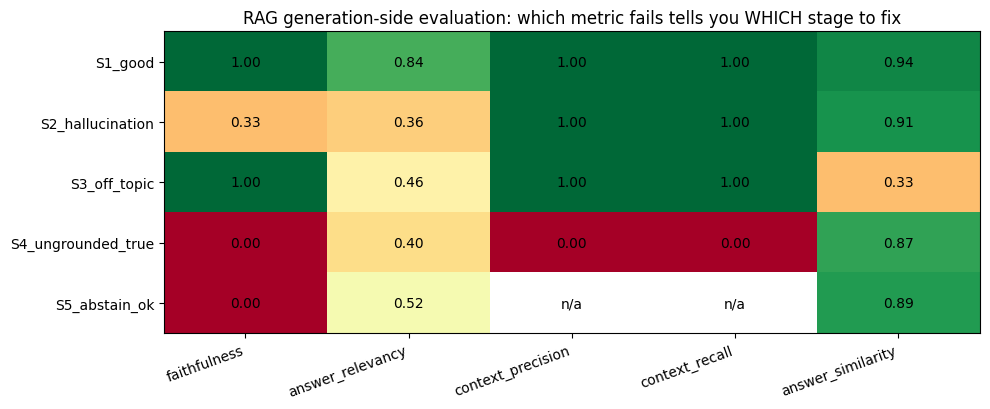

n/a = unanswerable question (recall/precision undefined; abstention is scored separately).


In [17]:
# ============================================
# CELL 7: Visualization — metric heatmap per sample
# ============================================
metric_cols = ["faithfulness", "answer_relevancy", "context_precision", "context_recall", "answer_similarity"]
data = df[metric_cols].astype(float).values

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.imshow(np.ma.masked_invalid(data), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, "n/a" if np.isnan(data[i, j]) else f"{data[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_xticks(range(len(metric_cols))); ax.set_xticklabels(metric_cols, rotation=20, ha="right")
ax.set_yticks(range(len(df))); ax.set_yticklabels(df["id"])
ax.set_title("RAG generation-side evaluation: which metric fails tells you WHICH stage to fix")
plt.tight_layout(); plt.show()
print("n/a = unanswerable question (recall/precision undefined; abstention is scored separately).")